In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import csv

# Configuration
RESULTS_DIR = Path("../results")


In [2]:
# Define time range for concatenating measurements
start_str = "2026-01-05 19:07:10"  # inclusive start
end_str = "2026-01-05 23:59:02"  

# type_meas = "full_swing" # full_swing
type_meas = "v_meas" # full_swing

fourier_analysis = False
plot_data = True


In [3]:
%matplotlib widget

In [4]:
start_dt = datetime.datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S")
end_dt = datetime.datetime.strptime(end_str, "%Y-%m-%d %H:%M:%S")
if end_dt <= start_dt:
    raise ValueError("End datetime must be after start datetime")

# Find all files in the specified time range
files_in_range = []

current_date = start_dt.date()
while current_date <= end_dt.date():
    for file in sorted((RESULTS_DIR / current_date.strftime("%Y") / current_date.strftime("%m") / current_date.strftime("%d")).glob(f"{type_meas}_*.json")):
        try:
            stamp = file.stem.split("_")[-1]  # expects v_meas_YYYYMMDD-HHMMSS.json
            dt = datetime.datetime.strptime(stamp, "%Y%m%d-%H%M%S")
        except ValueError:
            continue  # skip files that don't match the timestamp pattern
        if start_dt <= dt <= end_dt:
            print(dt)
            files_in_range.append((dt, file))
    current_date += datetime.timedelta(days=1)


2026-01-05 19:07:13
2026-01-05 19:07:20
2026-01-05 19:07:28
2026-01-05 19:07:36
2026-01-05 19:07:45
2026-01-05 19:07:53
2026-01-05 19:08:00
2026-01-05 19:08:08
2026-01-05 19:08:16
2026-01-05 19:08:25
2026-01-05 19:08:32
2026-01-05 19:08:40
2026-01-05 19:08:48
2026-01-05 19:08:57
2026-01-05 19:09:05
2026-01-05 19:09:12
2026-01-05 19:09:20
2026-01-05 19:09:29
2026-01-05 19:09:37
2026-01-05 19:09:44
2026-01-05 19:09:52
2026-01-05 19:10:01
2026-01-05 19:10:09
2026-01-05 19:10:17
2026-01-05 19:10:24
2026-01-05 19:10:33
2026-01-05 19:10:41
2026-01-05 19:10:49
2026-01-05 19:10:56
2026-01-05 19:11:05
2026-01-05 19:11:13
2026-01-05 19:11:21
2026-01-05 19:11:29
2026-01-05 19:11:36
2026-01-05 19:11:45
2026-01-05 19:11:53
2026-01-05 19:12:01
2026-01-05 19:12:08
2026-01-05 19:12:17
2026-01-05 19:12:25
2026-01-05 19:12:33
2026-01-05 19:12:41
2026-01-05 19:12:49
2026-01-05 19:12:57
2026-01-05 19:13:05
2026-01-05 19:13:13
2026-01-05 19:13:22
2026-01-05 19:13:29
2026-01-05 19:13:37
2026-01-05 19:13:45


In [5]:

if not files_in_range:
    print("No files found in the specified range.")
else:
    # Load and concatenate data from all files
    concat_time = []
    concat_voltage = []
    base_dt = files_in_range[0][0]  # anchor absolute time to the first capture

    for dt, file in files_in_range:
        with open(file, "r") as f:
            d = json.load(f)
        t = np.array(d["time_s"], dtype=float)
        v = np.array(d["voltage_data_v"], dtype=float)
        if len(t) == 0 or len(v) == 0:
            continue

        # Offset this capture so its start reflects the true wall-clock interval
        offset = (dt - base_dt).total_seconds()
        concat_time.append(t + offset)
        concat_voltage.append(v)

    if not concat_time:
        print("All files in range were empty after parsing.")
    else:
        concat_time = np.concatenate(concat_time)
        concat_voltage = np.concatenate(concat_voltage)
        
        print(f"Loaded {len(files_in_range)} files")
        print(f"Total data points: {len(concat_voltage)}")
        print(f"Time range: {base_dt} to {base_dt + datetime.timedelta(seconds=concat_time[-1])}")



Loaded 2158 files
Total data points: 17264000
Time range: 2026-01-05 19:07:13 to 2026-01-05 23:59:01.999000


In [6]:
a = [datetime.datetime.strptime("2025-12-29 12:51:12", "%Y-%m-%d %H:%M:%S")]*len(concat_time)
b = np.linspace(min(concat_voltage),max(concat_voltage),len(concat_time))


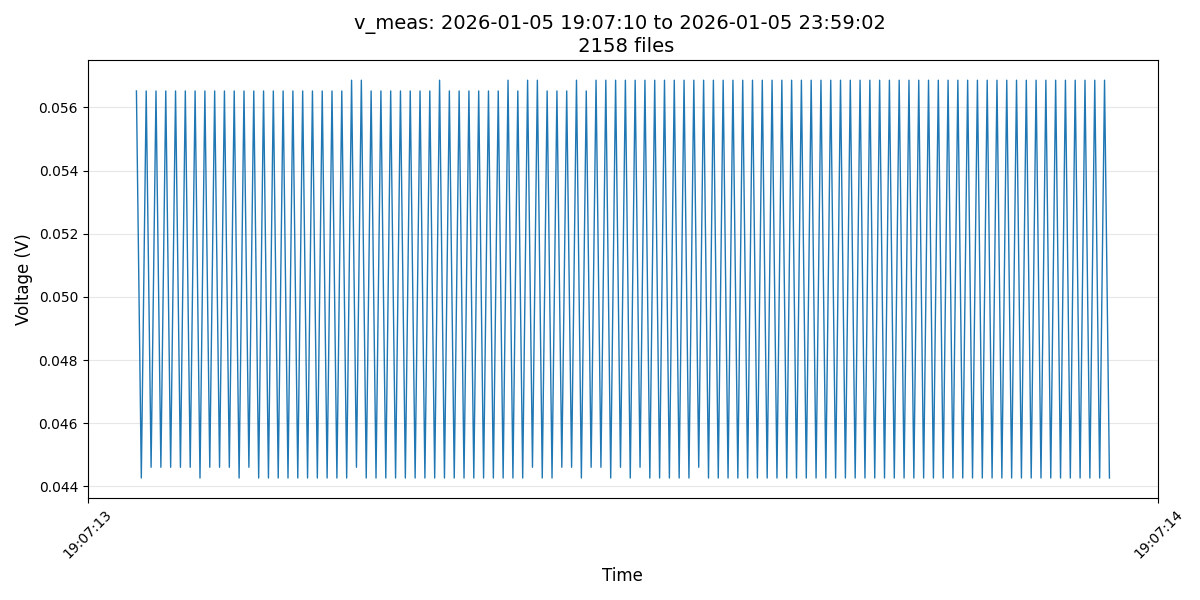


Concatenated voltage stats:
  Min: -0.063637 V
  Max: 0.088860 V
  Mean: 0.053522 V
  Std: 0.017163 V

Files included (chronological):
  2026-01-05 19:07:13 -> v_meas_20260105-190713.json
  2026-01-05 19:07:20 -> v_meas_20260105-190720.json
  2026-01-05 19:07:28 -> v_meas_20260105-190728.json
  2026-01-05 19:07:36 -> v_meas_20260105-190736.json
  2026-01-05 19:07:45 -> v_meas_20260105-190745.json
  2026-01-05 19:07:53 -> v_meas_20260105-190753.json
  2026-01-05 19:08:00 -> v_meas_20260105-190800.json
  2026-01-05 19:08:08 -> v_meas_20260105-190808.json
  2026-01-05 19:08:16 -> v_meas_20260105-190816.json
  2026-01-05 19:08:25 -> v_meas_20260105-190825.json
  2026-01-05 19:08:32 -> v_meas_20260105-190832.json
  2026-01-05 19:08:40 -> v_meas_20260105-190840.json
  2026-01-05 19:08:48 -> v_meas_20260105-190848.json
  2026-01-05 19:08:57 -> v_meas_20260105-190857.json
  2026-01-05 19:09:05 -> v_meas_20260105-190905.json
  2026-01-05 19:09:12 -> v_meas_20260105-190912.json
  2026-01-05 19:

In [13]:
# Plot the concatenated data
if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
    # Convert time to actual datetime objects starting from the first measurement time
    # base_dt is the datetime of the first measurement
    # concat_time is in seconds relative to base_dt, so add timedelta to base_dt
    from datetime import timedelta
    import matplotlib.dates as mdates
    if fourier_analysis:
        export_filename_csv = f"{type_meas}_{start_str}_{end_str}.csv"
        with open(export_filename_csv, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['time_s', 'voltage_v'])  # Header
            # Write data in chunks to handle large files efficiently
            chunk_size = 10000
            concat_time = concat_time[::10]
            concat_voltage = concat_voltage[::10]
            for i in range(0, len(concat_time), chunk_size):
                chunk = np.column_stack([concat_time[i:i+chunk_size], concat_voltage[i:i+chunk_size]])
                writer.writerows(chunk)
        print(f"Data exported to CSV: {export_filename_csv}")
        print(f"  Rows: {len(concat_time)}")
        
    concat_datetime = [base_dt + timedelta(seconds=float(t)) for t in concat_time]

    if plot_data:

        plt.figure(figsize=(12, 6))
        plt.plot(concat_datetime[1000:1200], concat_voltage[1000:1200], linewidth=1)
        # plt.plot(a,b,linewidth=1)
        # plt.plot(concat_voltage[:], linewidth=1)
        plt.xlabel("Time", fontsize=12)
        # Format x-axis to show time nicely
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
        plt.xticks(rotation=45)
        plt.ylabel("Voltage (V)", fontsize=12)
        plt.title(
            f"{type_meas}: {start_str} to {end_str} \n {len(files_in_range)} files",
            fontsize=14,
        )
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.savefig(f"{type_meas}_{start_str}_{end_str}.png")

        print("\nConcatenated voltage stats:")
        print(f"  Min: {np.min(concat_voltage):.6f} V")
        print(f"  Max: {np.max(concat_voltage):.6f} V")
        print(f"  Mean: {np.mean(concat_voltage):.6f} V")
        print(f"  Std: {np.std(concat_voltage):.6f} V")
        print("\nFiles included (chronological):")
        for dt, file in files_in_range:
            print(f"  {dt} -> {file.name}")
else:
    print("No data loaded. Please run the data loading cell first.")

# Not Used

In [8]:
# # Calculate and plot the phase
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     # Select the data range (same as used in phase function definition)
#     start_idx = 400  # Starting from 4 hours in (assuming 1000 samples per second)
#     time_selected = concat_time[start_idx:]
#     voltage_selected = concat_voltage[start_idx:]
    
#     # Calculate phase using the phase function
#     phase_shift = phase(voltage_selected, time_selected, v_min, v_max)
    
#     # Plot the phase
#     plt.figure(figsize=(12, 6))
#     plt.plot(time_selected, phase_shift, linewidth=0.5)
#     plt.xlabel("Time (s)", fontsize=12)
#     plt.ylabel("Phase (radians)", fontsize=12)
#     plt.title("Phase Shift vs Time", fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()
    
#     # # Print phase statistics
#     # print("\nPhase statistics:")
#     # print(f"  Min phase: {np.min(phase_shift):.6f} rad ({np.min(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Max phase: {np.max(phase_shift):.6f} rad ({np.max(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Mean phase: {np.mean(phase_shift):.6f} rad ({np.mean(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Phase range: {np.max(phase_shift) - np.min(phase_shift):.6f} rad ({(np.max(phase_shift) - np.min(phase_shift)) * 180 / np.pi:.2f}°)")
#     # print(f"  Number of points: {len(phase_shift)}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [9]:
# # Export concat_time and concat_voltage data
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     import csv
    
#     # Create filename with timestamp range
#     filename_base = f"concatenated_data_{start_str.replace(' ', '_').replace(':', '-')}_to_{end_str.replace(' ', '_').replace(':', '-')}"
    
#     # Option 1: Export to CSV (easy to open in Excel/spreadsheet programs)
#     export_filename_csv = f"{filename_base}.csv"
#     with open(export_filename_csv, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(['time_s', 'voltage_v'])  # Header
#         # Write data in chunks to handle large files efficiently
#         chunk_size = 10000
#         for i in range(0, len(concat_time), chunk_size):
#             chunk = np.column_stack([concat_time[i:i+chunk_size], concat_voltage[i:i+chunk_size]])
#             writer.writerows(chunk)
#     print(f"Data exported to CSV: {export_filename_csv}")
#     print(f"  Rows: {len(concat_time)}")
    
#     # Option 2: Export to NPZ (numpy compressed format - preserves precision and is efficient)
#     export_filename_npz = f"{filename_base}.npz"
#     # Save base_dt as ISO format string for easy reconstruction
#     np.savez(export_filename_npz, 
#              concat_time=concat_time, 
#              concat_voltage=concat_voltage, 
#              base_dt_str=base_dt.isoformat(),
#              start_str=start_str,
#              end_str=end_str)
#     print(f"Data exported to NPZ: {export_filename_npz}")
#     print(f"  To load: data = np.load('{export_filename_npz}'); time = data['concat_time']; voltage = data['concat_voltage']")
#     print(f"  base_dt: {base_dt.isoformat()}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [10]:
# Exporting the data


In [11]:
# v_min = 0.02489
# v_max = 0.0644

# v_min = min(v_min, np.min(concat_voltage[4*3600*1000:]))
# v_max = max(v_max, np.max(concat_voltage[4*3600*1000:]))


# def phase(v, t,v_min,v_max):
#     demeaned = v - (v_min + v_max)/2
#     swing = (v_max - v_min)/2
#     phase_shift = np.arcsin(demeaned/swing)
#     return phase_shift